In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

*Particle Fitler Notes* 

y_t = f_t + v_t 
f_t: The market noise 
f_t: The latent fair price (What we are trading/looking for)

The Particle filter is a Sequential Monte Carlo model
- Assuming a Non- Gaussian distribution of returns

Fair Value
f_t = f_t-1 + d_t + error
- This value evolves randomly

Drift
d_t = rho*d_t-1 + (1 - rho)mu * nu_t
- Drift term behavoir mean reverts

error, nu, and nouse terms ~ N(0, sigma^2)


*Key Assumptions*

1. Hidden Vair Value exists
2. State evolution follows stochastic process
3. Observation noise model reasonably specified
4. Posterier can be approximated via finite particles
5. Fat tails/ nonlinear pricing distributions are why the particle filter can determine the true fair price

/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_3734/1939483273.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('SPY', start='2018-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


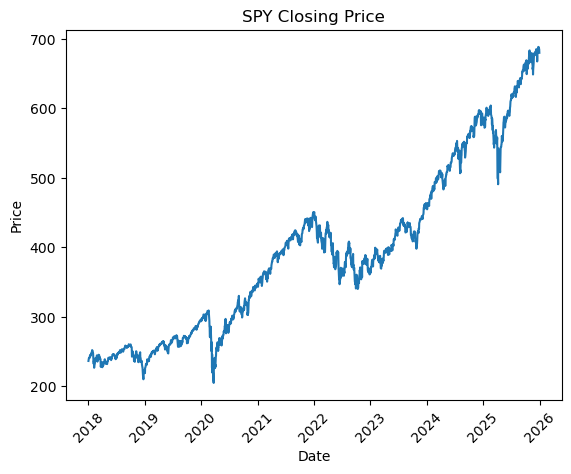

In [22]:
data = yf.download('SPY', start='2018-01-01', end='2026-01-01')
data.index = pd.to_datetime(data.index)
df = data['Close']
plt.plot(df)
plt.title('SPY Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()


In [23]:
df['log_price'] = np.log(df['SPY'])
df.dropna()
df


/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_3734/701921535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_price'] = np.log(df['SPY'])


Ticker,SPY,log_price
Date,,
2018-01-02,236.562134,5.466211
2018-01-03,238.058395,5.472516
2018-01-04,239.061829,5.476722
2018-01-05,240.654984,5.483364
2018-01-08,241.095032,5.485191
...,...,...
2025-12-24,688.499695,6.534515
2025-12-26,688.429871,6.534413
2025-12-29,685.976562,6.530843


In [24]:
#Initialize Particles
N = 300 #Particles are the items that will determine price movements

np.random.seed(42)

particles = np.random.normal(loc = df['log_price'].iloc[0],
                             scale = 0.1,
                             size = N
)

weights = np.ones(N)/N

Text(0.5, 1.0, 'Initial Particle Distribution')

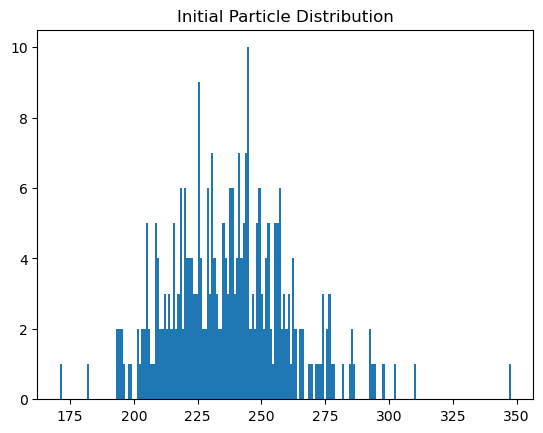

In [25]:
plt.hist(np.exp(particles), bins = 200)
plt.title("Initial Particle Distribution")

In [26]:
#Fair Latent Price
process_noise = .003
particles = particles + np.random.normal(0, process_noise, N)


Bayesian Update

Observation Likelihood p(y_t | f_t)

Gaussian weights

w_i = exp(-((y_t - f_i)^2)/ 2*sigma^2)

In [27]:
#Bayesian Update
obs_noise = .01
obs = df['log_price'].iloc[1]

likelihood=np.exp(
-(obs-particles)**2/
(2*obs_noise**2)

)

weights*=likelihood
weights/=weights.sum()

In [28]:
#Estimate Fair Value
#E[f_t] = sum(w_i*f_i)

fair_estimate = np.sum(weights*particles)


In [29]:
#ESS: Effective Sample Size
#ESS = 1/sum((w_i)^2)

ESS = 1/np.sum(weights**2)
ESS #This shows the number of particles that 'matter' when we are pricing the fair value

np.float64(41.55164957148305)

In [30]:
def systematic_resample(particles,weights):
    N=len(weights)
    positions=(np.random.rand()+np.arange(N))/N
    cumulative=np.cumsum(weights)
    idx=np.searchsorted(
        cumulative,
        positions
    )
    return particles[idx]

In [ ]:
fair_values=[]

particles=np.random.normal(
df['log_price'].iloc[0], .01, N )

weights=np.ones(N)/N


for obs in df['log_price']:

    # Predict
    particles+=np.random.normal(0,.003,N)

    # Update
    likelihood=np.exp( -(obs-particles)**2/ (2*.01**2))

    weights*=likelihood
    weights/=weights.sum()

    fair=np.sum(weights*particles)

    fair_values.append(
    np.exp(fair)
    )

    ESS=1/np.sum(weights**2)

    if ESS<.5*N:
        particles=systematic_resample(particles, weights)
        weights=np.ones(N)/N

In [34]:
df

Ticker,SPY,log_price
Date,,
2018-01-02,236.562134,5.466211
2018-01-03,238.058395,5.472516
2018-01-04,239.061829,5.476722
2018-01-05,240.654984,5.483364
2018-01-08,241.095032,5.485191
...,...,...
2025-12-24,688.499695,6.534515
2025-12-26,688.429871,6.534413
2025-12-29,685.976562,6.530843


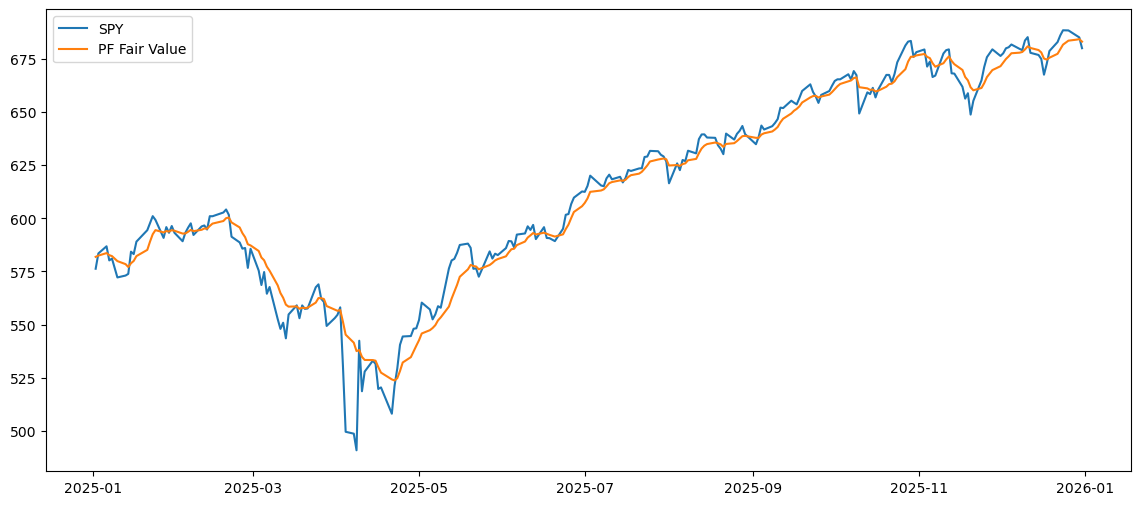

In [39]:
plt.figure(figsize=(14,6))

plot_df = df.loc["2025":"2026"]

plt.plot(
    plot_df.index,
    plot_df["SPY"],
    label="SPY"
)

plt.plot(
    plot_df.index,
    fair_values[-len(plot_df):],   # align fair values
    label="PF Fair Value"
)

plt.legend()
plt.show()

In [41]:
#Pricing Gap for trading system
gap = df['SPY'] - np.array(fair_values)
#Drift State

drift = np.zeros(N)
rho = 0.96
mu = .0002

drift = rho*drift + (1-rho) * mu + np.random.normal(0, .0005, N)

particles += drift

print(particles, drift)


[6.53028056 6.52295138 6.52905631 6.53545175 6.52578189 6.527755
 6.53627514 6.52050525 6.53986032 6.53762493 6.5326741  6.52290719
 6.5247677  6.52819775 6.52000218 6.52107035 6.52234179 6.5231744
 6.52121886 6.54532353 6.54405138 6.52002521 6.52835704 6.52697388
 6.52646087 6.53539867 6.52299837 6.52251158 6.51957236 6.51581056
 6.51732539 6.53959418 6.52962214 6.53057537 6.5271796  6.5169179
 6.52270269 6.52055964 6.52330744 6.52447921 6.51394938 6.5341555
 6.53194885 6.52814298 6.52646085 6.5179945  6.52276411 6.50728882
 6.52275341 6.52083817 6.5203718  6.52304891 6.52815498 6.52653511
 6.55068203 6.53098244 6.53051925 6.53737189 6.52593695 6.52471693
 6.53002914 6.51765906 6.52798034 6.53155772 6.53120288 6.52932014
 6.53724968 6.5338622  6.53028836 6.533377   6.52707391 6.53005863
 6.52672049 6.53057906 6.5115735  6.51531585 6.52672401 6.537435
 6.52660487 6.53536009 6.5305417  6.52958331 6.5342776  6.52189258
 6.51241899 6.52661785 6.52803873 6.52082323 6.52873223 6.52112423
 6